# Library used in this project (Ecommerce sales analysis)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Data extraction

In [3]:
df= pd.read_csv("training_basket.csv")

In [84]:
df


,Order_ID,Order_Date,Customer_Age,Gender,City,Category,Product,Quantity,Unit_Price,Payment_Mode,Rating,Sales,Year,Month,Age_Group
0,1001,2025-01-05,25,Male,Delhi,Electronics,Laptop,1,55000,UPI,5,55000,2025,1,18–25
1,1002,2025-01-07,32,Female,Mumbai,Clothing,Jeans,2,1800,Card,4,3600,2025,1,26–35
2,1003,2025-01-10,28,Male,Bangalore,Electronics,Mobile,1,22000,UPI,5,22000,2025,1,26–35
3,1004,2025-01-12,41,Female,Delhi,Home,Chair,4,2500,Cash,3,10000,2025,1,36–45
4,1005,2025-01-15,35,Male,Chennai,Clothing,Shirt,3,1200,Card,4,3600,2025,1,26–35
5,1006,2025-01-18,29,Female,Mumbai,Electronics,Headphones,2,2500,UPI,5,5000,2025,1,26–35
6,1007,2025-01-20,45,Male,Kolkata,Home,Table,1,7000,Cash,4,7000,2025,1,36–45
7,1008,2025-01-22,23,Female,Delhi,Clothing,Dress,2,2200,Card,5,4400,2025,1,18–25
8,1009,2025-01-25,38,Male,Bangalore,Electronics,Tablet,1,18000,UPI,4,18000,2025,1,36–45
9,1010,2025-01-28,31,Female,Chennai,Home,Lamp,3,1500,Cash,3,4500,2025,1,26–35


# pahse 1 Understanding the Dataset

### How many records and columns are present?
df.shape

In [5]:
df.shape

(26, 11)

In [6]:
#What are the data types of each column?

In [7]:
df.dtypes

Order_ID         int64
Order_Date      object
Customer_Age     int64
Gender          object
City            object
Category        object
Product         object
Quantity         int64
Unit_Price       int64
Payment_Mode    object
Rating           int64
dtype: object

In [8]:
#Which columns are numerical and categorical?
#.columns,Gets the column names (as pandas Index)
#.tolist(),Converts that Index into a normal Python list

In [9]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numerical columns:")
print(numerical_cols)
print("\nCategorical columns:")
print(categorical_cols)
print()

Numerical columns:
['Order_ID', 'Customer_Age', 'Quantity', 'Unit_Price', 'Rating']

Categorical columns:
['Order_Date', 'Gender', 'City', 'Category', 'Product', 'Payment_Mode']



In [10]:
#What is the average customer age?
average_age = df["Customer_Age"].mean()
print("Average Customer Age:", average_age)

Average Customer Age: 33.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order_ID      26 non-null     int64 
 1   Order_Date    26 non-null     object
 2   Customer_Age  26 non-null     int64 
 3   Gender        26 non-null     object
 4   City          26 non-null     object
 5   Category      26 non-null     object
 6   Product       26 non-null     object
 7   Quantity      26 non-null     int64 
 8   Unit_Price    26 non-null     int64 
 9   Payment_Mode  26 non-null     object
 10  Rating        26 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 2.4+ KB


In [12]:
#What is the average quantity per order?

In [13]:
average_Qty = df["Quantity"].mean()
print("Average quantity per_order:", average_Qty)

Average quantity per_order: 1.8461538461538463


In [14]:
#What is the average product rating?

In [15]:
Average_pro_rating= df["Rating"].mean()
print("Average product rating:", Average_pro_rating)

Average product rating: 4.269230769230769


# Phase 2 — Data Quality Analysis

In [16]:
#Are there any missing values?

In [17]:
df.isnull().sum()

Order_ID        0
Order_Date      0
Customer_Age    0
Gender          0
City            0
Category        0
Product         0
Quantity        0
Unit_Price      0
Payment_Mode    0
Rating          0
dtype: int64

### Are there duplicate transactions?

In [18]:
duplicate= df.duplicated().sum()
print("Number of duplicate transaction:",duplicate)


Number of duplicate transaction: 0


In [85]:
df["Order_ID"].duplicated().sum()

np.int64(1)

### Is Order_Date stored correctly?

In [19]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])


In [20]:
pd.to_datetime(df["Order_Date"])

0    2025-01-05
1    2025-01-07
2    2025-01-10
3    2025-01-12
4    2025-01-15
5    2025-01-18
6    2025-01-20
7    2025-01-22
8    2025-01-25
9    2025-01-28
10   2025-02-02
11   2025-02-05
12   2025-02-08
13   2025-02-10
14   2025-02-14
15   2025-02-17
16   2025-02-20
17   2025-02-23
18   2025-02-25
19   2025-02-27
20   2025-02-27
21   2025-03-02
22   2025-03-05
23   2025-03-08
24   2025-03-10
25   2025-03-13
Name: Order_Date, dtype: datetime64[ns]

In [21]:
#Are there any invalid quantities?

In [22]:
print(df[df["Quantity"] <=0])

Empty DataFrame
Columns: [Order_ID, Order_Date, Customer_Age, Gender, City, Category, Product, Quantity, Unit_Price, Payment_Mode, Rating]
Index: []


In [23]:
#Are there any invalid ratings?

In [24]:
print(df[(df['Rating'] < 1) | (df['Rating'] > 5)])

Empty DataFrame
Columns: [Order_ID, Order_Date, Customer_Age, Gender, City, Category, Product, Quantity, Unit_Price, Payment_Mode, Rating]
Index: []


# Phase 3 — Feature Engineering

In [25]:
#1. Sales

In [26]:
df["Sales"] =df["Quantity"] *df["Unit_Price"]

In [27]:
#2. Year

In [28]:
df["Year"] = pd.to_datetime(df["Order_Date"]).dt.year

In [29]:
#3. Month 


In [30]:
df["Month"] = pd.to_datetime(df["Order_Date"]).dt.month

In [31]:
#4. Age_Group 
#Extract the age_group a/c to their category

In [32]:
bins = [18, 25, 35, 45, 200]
labels = ["18–25", "26–35", "36–45", "46+"]

df["Age_Group"] = pd.cut(df["Customer_Age"], bins=bins, labels=labels)  #bins= use to store variable 
print(df[["Customer_Age", "Age_Group"]])                                #lables= use to store group_name

    Customer_Age Age_Group
0             25     18–25
1             32     26–35
2             28     26–35
3             41     36–45
4             35     26–35
5             29     26–35
6             45     36–45
7             23     18–25
8             38     36–45
9             31     26–35
10            27     26–35
11            36     36–45
12            42     36–45
13            24     18–25
14            33     26–35
15            39     36–45
16            26     26–35
17            44     36–45
18            30     26–35
19            37     36–45
20            37     36–45
21            29     26–35
22            34     26–35
23            40     36–45
24            22     18–25
25            31     26–35


# Phase 4 — Business KPI Analysis

## KPI 1 — Total Revenue

In [33]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 388200


## KPI 2 — Total Orders

In [88]:
number_of_order= df["Order_ID"].count()
print("Number of Order:",number_of_order) # ask it sir that what we have to use count()or nunique() funtion here

Number of Order: 26


## KPI 3 — Total Quantity Sold

In [35]:
number_of_product_sold = df["Quantity"].sum()
print("Number of product sold:",number_of_product_sold)

Number of product sold: 48


## KPI 4 — Average Order Value

In [36]:
total_sales= df["Sales"].sum()
total_order= df["Order_ID"].nunique()

avg_ord_val = total_sales / total_order

print("Average order value:",avg_ord_val)

Average order value: 15528.0


## KPI 5 — Average Rating

In [37]:
total_rating= df["Rating"].sum()
no_of_rating= df["Rating"].count()

avg_rat= total_rating / no_of_rating

print("Average order Rating:", avg_rat)

Average order Rating: 4.269230769230769


# Phase 5 — Product Analysis

### Which product has the highest sales

In [38]:
df.groupby("Product")["Sales"].sum().idxmax() #idxmax give the name of the product with heighest sales

'Laptop'

### Which product has the highest quantity sold?

In [39]:
df.groupby("Product")["Quantity"].sum().idxmax()

'Shirt'

### Which product has the highest average rating?

In [40]:
df.groupby("Product")["Rating"].mean().idxmax()

'Laptop'

### Which 5 products generate the highest revenue?

In [41]:
df.groupby("Product")["Sales"].sum().head()

Product
Chair         15000
Dress          6600
Headphones    17500
Jeans         10800
Lamp           4500
Name: Sales, dtype: int64

### Which products have relatively low sales?

In [42]:
df.groupby("Product")["Sales"].sum().sort_values().head()

Product
Lamp      4500
Dress     6600
Jeans    10800
Shirt    10800
Chair    15000
Name: Sales, dtype: int64

### visualization

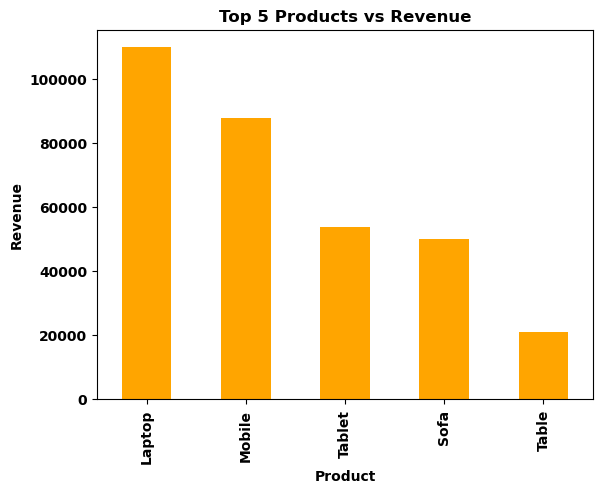

In [43]:
#Create a bar chart: Top Products vs Revenue

top_products = df.groupby("Product")["Sales"].sum().nlargest(5)

top_products.plot(kind="bar", color="orange")

plt.title("Top 5 Products vs Revenue", fontweight="bold")
plt.xlabel("Product", fontweight="bold")
plt.ylabel("Revenue", fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.show()

# Phase 6 — Category Analysis

### Which category generates the highest revenue?

In [44]:
df.groupby("Category")["Sales"].sum().idxmax()

'Electronics'

### Which category sells the highest quantity?

In [45]:
df.groupby("Category")["Quantity"].sum().idxmax()

'Clothing'

### Which category has the highest average rating?

In [46]:
df.groupby("Category")["Rating"].mean().idxmax()

'Electronics'

### What percentage of total revenue comes from each category?

#### formula= Category Revenue ÷ Total Revenue × 100

In [47]:
category_sales = df.groupby("Category")["Sales"].sum()
percentage = (category_sales / category_sales.sum() * 100).round(2)
print (percentage)

Category
Clothing        7.26
Electronics    69.42
Home           23.31
Name: Sales, dtype: float64


### Category-wise Sales Bar Chart

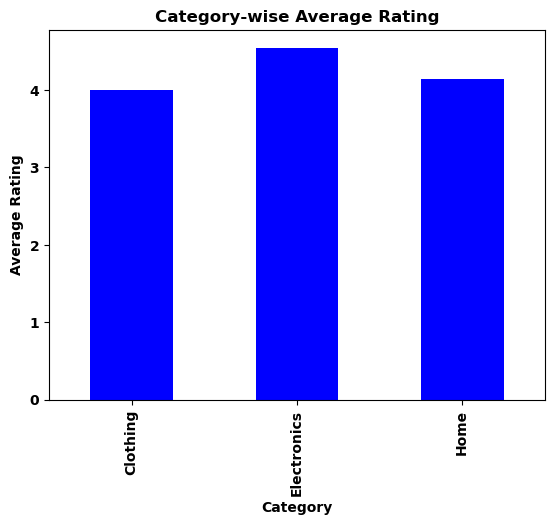

In [48]:

import matplotlib.pyplot as plt

rating = df.groupby("Category")["Rating"].mean()

rating.plot(kind="bar", color="blue")

plt.title("Category-wise Average Rating", fontweight="bold")
plt.xlabel("Category", fontweight="bold")
plt.ylabel("Average Rating", fontweight="bold")
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.show()

### Category-wise Average Rating Chart

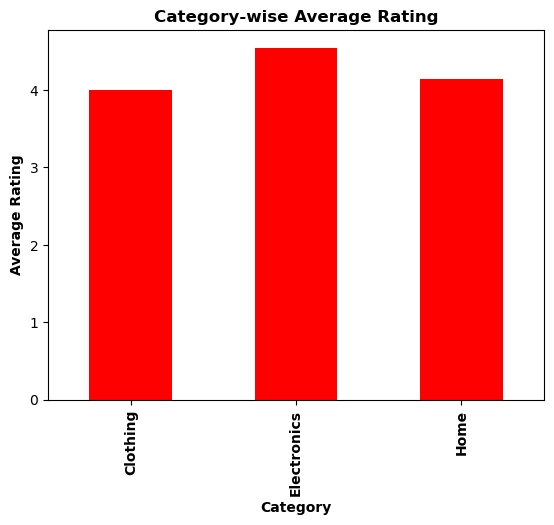

In [49]:
rating = df.groupby("Category")["Rating"].mean()

rating.plot(kind="bar", color="red")

plt.title("Category-wise Average Rating", fontweight="bold")
plt.xlabel("Category", fontweight="bold")
plt.ylabel("Average Rating", fontweight="bold")
plt.xticks(fontweight="bold")
plt.show()

# Phase 7 — City Analysis

### Which city generates the highest revenue?

In [50]:
df.groupby("City")["Sales"].sum().idxmax()

'Delhi'

### Which city has the highest number of orders?

In [51]:
df.groupby("City")["Order_ID"].count().idxmax()

'Chennai'

### Which city sells the highest quantity?

In [52]:
df.groupby("City")["Quantity"].sum().idxmax()

'Chennai'

### Which city has the highest average rating?

In [53]:
df.groupby("City")["Rating"].mean().idxmax()

'Delhi'

### What percentage of total revenue comes from each city?

In [54]:
city_sales = df.groupby("City")["Sales"].sum()
print((city_sales / df["Sales"].sum() * 100).round(2))

City
Bangalore    17.08
Chennai      13.27
Delhi        33.90
Kolkata      15.25
Mumbai       20.50
Name: Sales, dtype: float64


### visiualization

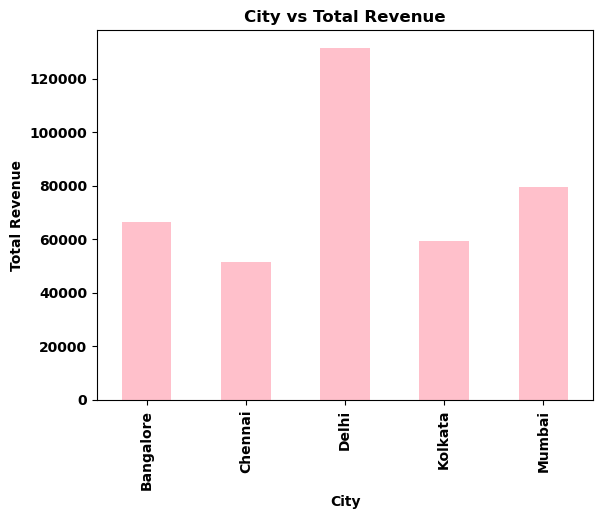

In [55]:

city_sales = df.groupby("City")["Sales"].sum()

city_sales.plot(kind="bar", color="pink")

plt.title("City vs Total Revenue", fontweight="bold")
plt.xlabel("City", fontweight="bold")
plt.ylabel("Total Revenue", fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.show()

# Phase 8 — Customer Analysis

### Which gender generates more revenue?

In [56]:
df.groupby("Gender")["Sales"].sum().idxmax()

'Male'

### Which age group places the most orders?

In [57]:
#default behavior of groupby() will change in a future version, that why we use observed=true:
df.groupby("Age_Group",observed=True)["Order_ID"].nunique().idxmax()

'26–35'

### Which age group generates the highest revenue?

In [58]:
df.groupby("Age_Group",observed=True)["Sales"].sum().idxmax()

'26–35'

### Which age group has the highest average rating?

In [59]:
df.groupby("Age_Group",observed=True)["Rating"].mean().idxmax()

'26–35'

### Is there a relationship between customer age and sales?

In [60]:
df.groupby("Age_Group",observed=True)["Sales"].mean().idxmax()

'18–25'

# Visualizations

### Gender-wise Sales Bar Chart

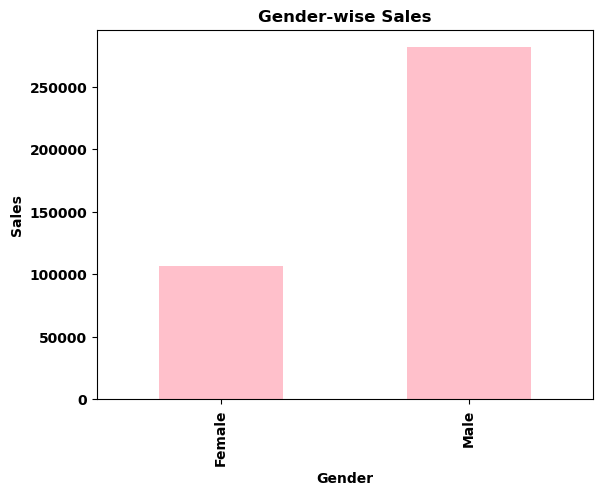

In [61]:
gender_sales = df.groupby("Gender")["Sales"].sum()

gender_sales.plot(kind="bar", color="pink")

plt.title("Gender-wise Sales", fontweight="bold")
plt.xlabel("Gender", fontweight="bold")
plt.ylabel("Sales", fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.show()

### Age Group Distribution

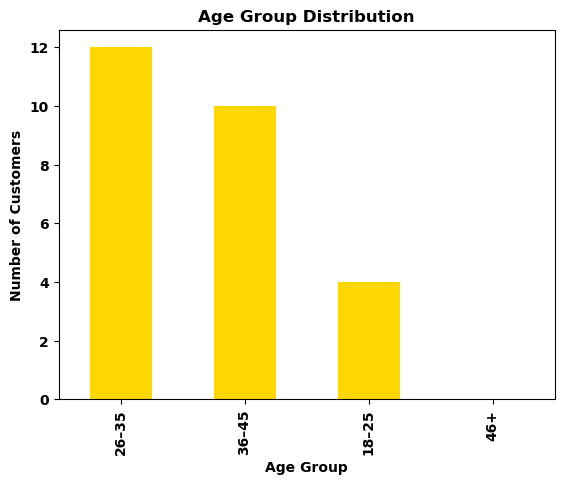

In [62]:
age_count = df["Age_Group"].value_counts()

age_count.plot(kind="bar", color="gold")

plt.title("Age Group Distribution", fontweight="bold")
plt.xlabel("Age Group", fontweight="bold")
plt.ylabel("Number of Customers", fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.show()

### Age vs Sales Scatter Plot

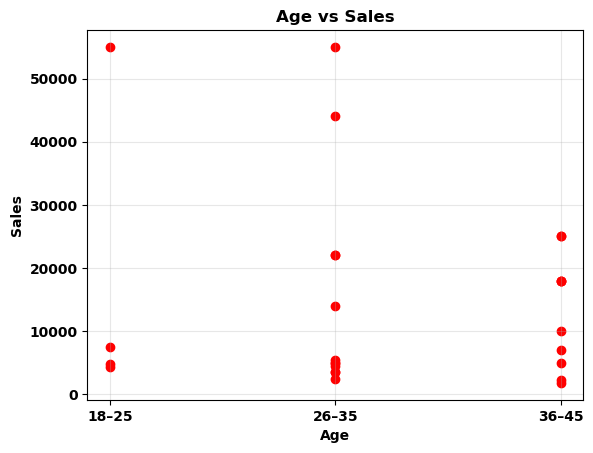

In [63]:
import matplotlib.pyplot as plt

plt.scatter(df["Age_Group"], df["Sales"], color="red")

plt.title("Age vs Sales", fontweight="bold")
plt.xlabel("Age", fontweight="bold")
plt.ylabel("Sales", fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(alpha=0.3)
plt.show()

# Phase 9 — Payment Analysis

### Which payment method is used most frequently?

In [64]:
most_used_payment = df["Payment_Mode"].value_counts().idxmax()
print(most_used_payment)

UPI


### Which payment method generates the highest revenue?

In [65]:
df.groupby("Payment_Mode")["Sales"].sum().idxmax()

'UPI'

### Does the average order value differ by payment method?

In [66]:
aov = df.groupby("Payment_Mode")["Sales"].mean()
print(aov.sort_values(ascending=False))

Payment_Mode
UPI     20663.636364
Card    12200.000000
Cash     8516.666667
Name: Sales, dtype: float64


## visualization

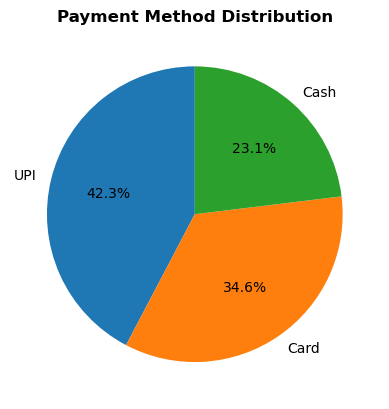

In [67]:
import matplotlib.pyplot as plt

payment_count = df["Payment_Mode"].value_counts()

plt.pie(payment_count,
        labels=payment_count.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Payment Method Distribution", fontweight="bold")
plt.show()

# Phase 10 — Time-Based Analysis

### Which month generated the highest revenue and lowest revenue??

In [68]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Month"] = df["Order_Date"].dt.month

print(df.groupby("Month")["Sales"].sum().sort_values(ascending=False))

Month
2    192900
1    133100
3     62200
Name: Sales, dtype: int64


### Is revenue increasing or decreasing?

In [69]:
monthly_sales = df.groupby("Month")["Sales"].sum()
print(monthly_sales)

Month
1    133100
2    192900
3     62200
Name: Sales, dtype: int64


In [70]:
# revenue is increasing in last two month and now it's decrease by high percentage 

### Which month had the highest number of orders?

In [71]:
df["Month"] = df["Order_Date"].dt.month
df.groupby("Month")["Order_Date"].nunique().sort_values(ascending=False)

Month
1    10
2    10
3     5
Name: Order_Date, dtype: int64

### Month vs Revenue using a Line Char

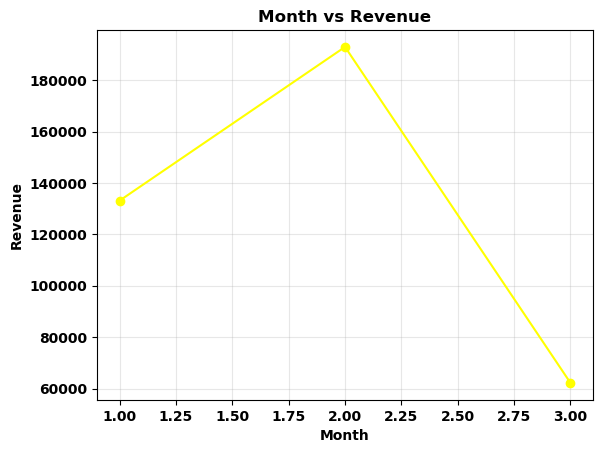

In [72]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot(kind="line", marker="o", color="yellow")

plt.title("Month vs Revenue", fontweight="bold")
plt.xlabel("Month", fontweight="bold")
plt.ylabel("Revenue", fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.grid(alpha=0.3)

plt.show()

# Phase 11 — Required Visualizations

### Category vs Sales Category performance

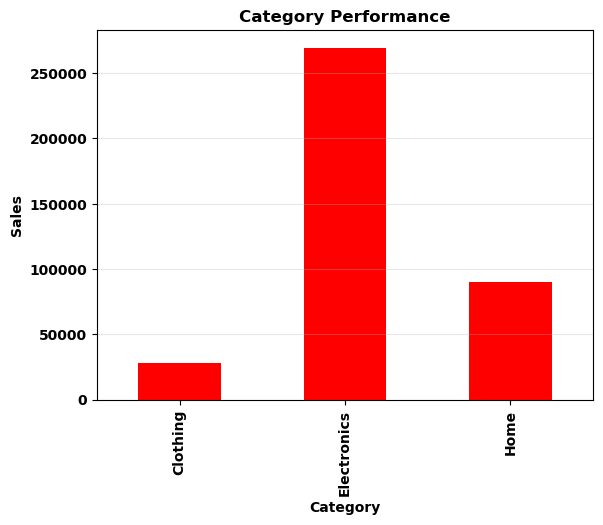

In [73]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar", color="red")

plt.title("Category Performance", fontweight="bold")
plt.xlabel("Category", fontweight="bold")
plt.ylabel("Sales", fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(axis="y", alpha=0.3)
plt.show()

### City vs Sales Market performance

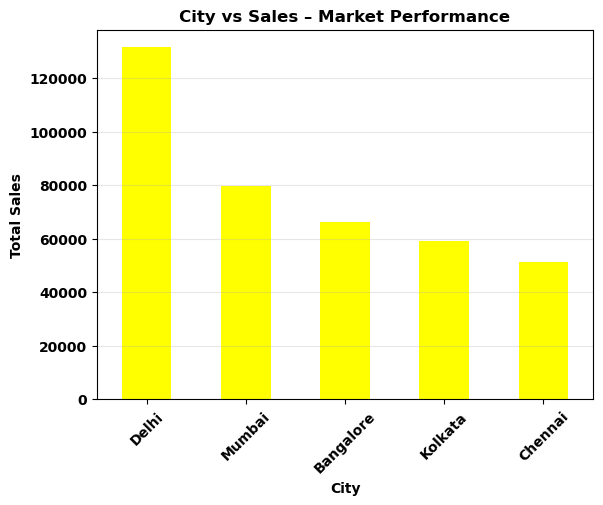

In [74]:
import matplotlib.pyplot as plt

city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)

city_sales.plot(kind="bar", color="yellow")

plt.title("City vs Sales – Market Performance", fontweight="bold")
plt.xlabel("City", fontweight="bold")
plt.ylabel("Total Sales", fontweight="bold")

plt.xticks(fontweight="bold", rotation=45)
plt.yticks(fontweight="bold")

plt.grid(axis="y", alpha=0.3)
plt.show()

### Top 5 Products vs Sales Product performance

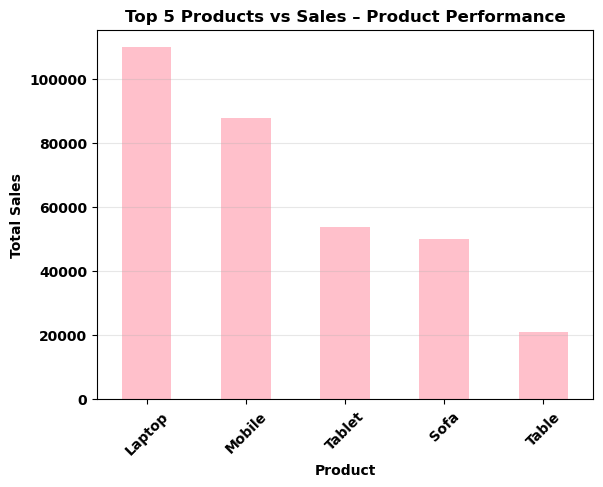

In [75]:
top_products = df.groupby("Product")["Sales"].sum().nlargest(5)

top_products.plot(kind="bar", color="pink")

plt.title("Top 5 Products vs Sales – Product Performance", fontweight="bold")
plt.xlabel("Product", fontweight="bold")
plt.ylabel("Total Sales", fontweight="bold")

plt.xticks(fontweight="bold", rotation=45)
plt.yticks(fontweight="bold")

plt.grid(axis="y", alpha=0.3)
plt.show()

### Payment Mode Pie Chart Payment preference

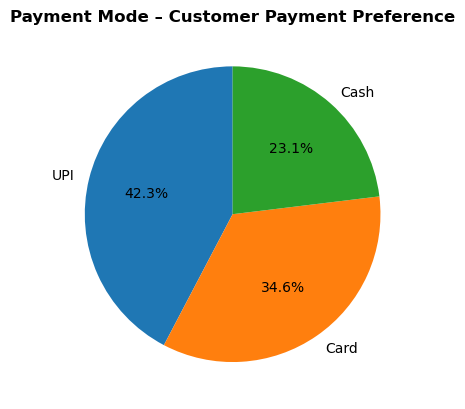

In [76]:
#payment_count → values used to create the slices.
#labels=payment_count.index → displays payment method names.
#autopct="%1.1f%%" → displays percentages like 35.5%.
#startangle=90 → starts the pie chart from a 90° angle, making it look cleaner.


payment_count = df["Payment_Mode"].value_counts()

plt.pie(payment_count,
        labels=payment_count.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Payment Mode – Customer Payment Preference", fontweight="bold")
plt.show()

### Customer Age Histogram Customer distribution

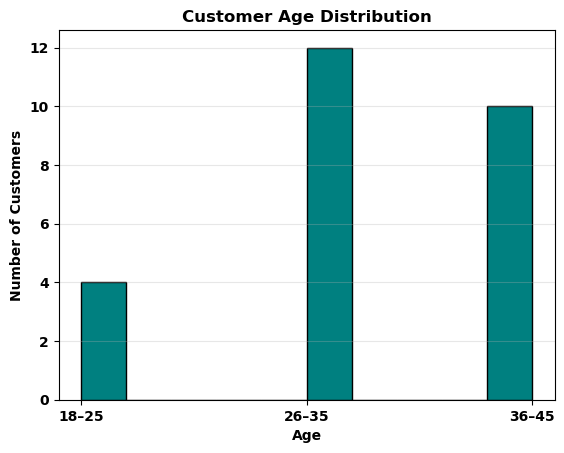

In [77]:

plt.hist(df["Age_Group"], bins=10, color="teal", edgecolor="black")

plt.title("Customer Age Distribution", fontweight="bold")
plt.xlabel("Age", fontweight="bold")
plt.ylabel("Number of Customers", fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(axis="y", alpha=0.3)
plt.show()

### Gender vs Sales Customer behavior

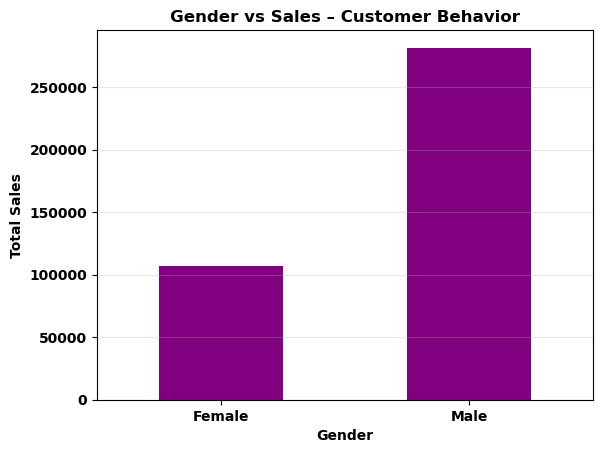

In [78]:

gender_sales = df.groupby("Gender")["Sales"].sum()

gender_sales.plot(kind="bar", color="purple")

plt.title("Gender vs Sales – Customer Behavior", fontweight="bold")
plt.xlabel("Gender", fontweight="bold")
plt.ylabel("Total Sales", fontweight="bold")

plt.xticks(fontweight="bold", rotation=0)
plt.yticks(fontweight="bold")

plt.grid(axis="y", alpha=0.3)
plt.show()

### Monthly Sales Line Chart Sales trend

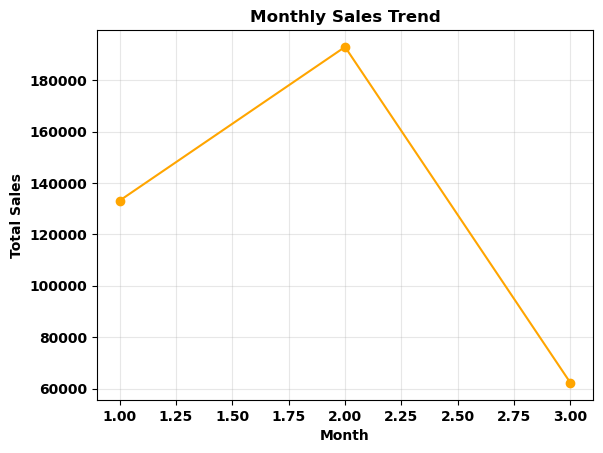

In [79]:

monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot(kind="line", marker="o", color="orange")

plt.title("Monthly Sales Trend", fontweight="bold")
plt.xlabel("Month", fontweight="bold")
plt.ylabel("Total Sales", fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(alpha=0.3)
plt.show()

### Age vs Sales Scatter Plot Relationship analysis

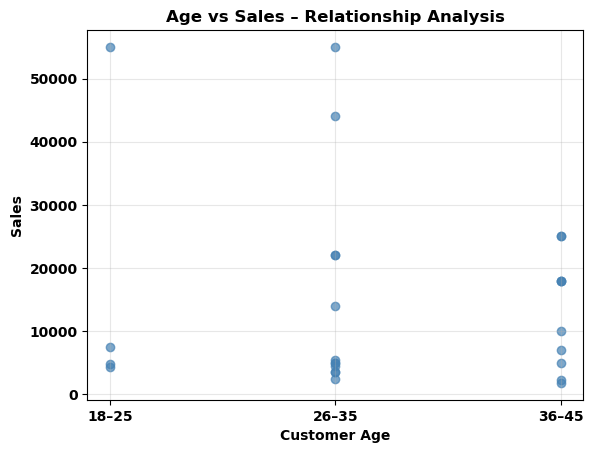

In [80]:

plt.scatter(df["Age_Group"], df["Sales"], color="steelblue", alpha=0.7)

plt.title("Age vs Sales – Relationship Analysis", fontweight="bold")
plt.xlabel("Customer Age", fontweight="bold")
plt.ylabel("Sales", fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(alpha=0.3)
plt.show()

# Phase 12 — Business Insight

# SUMMARY

# Phase 13 — Business Recommendations

# Question
## "Based on the available sales data, what should the e-commerce company do to increaserevenue and improve customer satisfaction?"